In [2]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [4]:
# donwnload dataset: https://drive.google.com/file/d/1PhfXJRPWHFGlcVOz_OCOM80SOUWzEmk5/view
!gdown 1PhfXJRPWHFGlcVOz_OCOM80SOUWzEmk5

Downloading...
From: https://drive.google.com/uc?id=1PhfXJRPWHFGlcVOz_OCOM80SOUWzEmk5
To: /content/auto-insurance.csv
100% 495/495 [00:00<00:00, 2.17MB/s]


In [5]:
# Step 2: Read
dataset_path = './auto-insurance.csv'
df = pd.read_csv(
    dataset_path,
    names=[
        'n_claims',
        'total_payment'
    ]
)
df

,n_claims,total_payment
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4
...,...,...
58,9,87.4
59,31,209.8
60,14,95.5
61,53,244.6


In [6]:
# Step 3: dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   n_claims       63 non-null     int64  
 1   total_payment  63 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


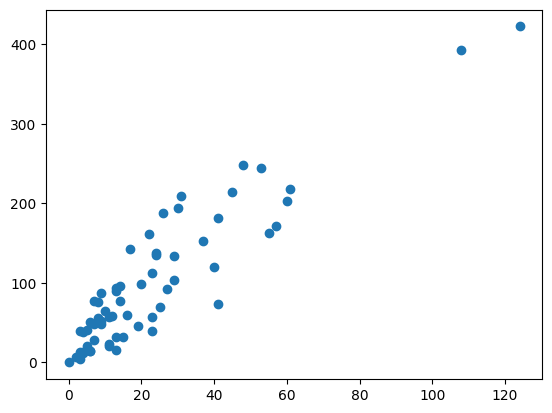

In [7]:
# Step 4: dataset visualization
X = df['n_claims']
y = df['total_payment']

plt.scatter(X, y);

In [9]:
# Step 5: Normalization
normalizer = StandardScaler()
df_normalized = normalizer.fit_transform(df)

In [13]:
# Step 6: Split X, y and create train, val, test dataset
X_normalized = df_normalized[:, 0].reshape(-1, 1)
y_normalized = df_normalized[:, 1]

In [14]:
val_size = 0.2
test_size = 0.125
random_state = 0
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_normalized, y_normalized,
    test_size=test_size,
    shuffle=is_shuffle,
    random_state=random_state
)
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    shuffle=is_shuffle,
    random_state=random_state
)

In [15]:
# Step 7: Train and evaluate SVM model
regressor = SVR()
regressor.fit(
    X_train,
    y_train
)

SVR()

In [17]:
y_val_pred = regressor.predict(X_val)
y_test_pred = regressor.predict(X_test)
val_mae = mean_absolute_error(y_val_pred, y_val)
val_mse = mean_squared_error(y_val_pred, y_val)
test_mae = mean_absolute_error(y_test_pred, y_test)
test_mse = mean_squared_error(y_test_pred, y_test)

print(f"Evaluation results on validation and test set:")
print(f"Mean Absolute Error\tval: {val_mae}\tTest: {test_mae}")
print(f"Mean Squared Error\tval: {val_mse}\tTest: {test_mse}")

Evaluation results on validation and test set:
Mean Absolute Error	val: 0.3516118770038519	Test: 0.2592554347918166
Mean Squared Error	val: 0.18885751110502652	Test: 0.09548912362968416
